# Preamble

In [18]:
from matplotlib import pyplot as plt # plotting
import math
import sklearn
#import GPy

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, DotProduct


import scipy
from tqdm import tqdm
import torch
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk, time
import torch.nn as nn

np.random.seed(101)


# Simulator

In [19]:
env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #alternative
obs, info = env.reset()
try:
    for i in range(200):
        action = env.action_space.sample()
        print(action)
        obs, reward, terminated, truncated, info = env.step(action) #random action
        #print(obs, reward)
        #env.render()
        time.sleep(1/24)
        if terminated or truncated:
            obs = env.reset()
finally: #this will always run
    env.close()

-1.6317104
-0.7718823
-2.898069
-0.72935325
0.38632217
2.2013483
-1.7553947
2.055689
0.3156593
-2.187069
-0.6033267
-2.57725
1.4245788
2.9874034
0.5697418
-2.9288073
1.7161406
0.9911668
1.5461136
1.3252223
2.0461297
-1.5076394
-2.9381192
-1.2278646
-0.5699017
-2.9720223
-2.6099017
-1.2936282
1.9806424
2.303023
2.1167943
1.3037405
0.24708681
-2.00345
1.931685
1.121811
0.92423195
1.5769379
-2.6077046
0.49848983
1.5511879
-2.576437
0.90741044
2.2612448
-2.3493428
0.06896194
-1.8203114
-2.0968728
0.90523446
-2.8046503
-1.3023177
2.9075587
-1.4490066
2.487167
-2.9409688
0.63568455
-0.20101728
0.80273265
2.6840925
-1.9011517
-1.2273477
1.4768205
1.9661673
1.5213078
1.531153
0.4991458
1.7222409
2.9916894
0.7399589
-0.9017092
0.91038615
2.0252075
-1.5859752
-0.6261471
0.3404935
-1.7734629
-1.822183
-0.7917787
1.7407933
0.3592348
0.7813301
-0.98473024
-0.6794608
-1.1710837
0.6456204
-2.8325186
-0.30551
0.5219833
-2.3171275
1.2203761
2.4809985
-2.4346356
-2.630085
-1.0622542
2.2847054
-2.603823


# Classes and fucntions

In [20]:
def GPR(self, state):
        kernel = self.parameters
        self.reg = GaussianProcessRegressor(kernel,alpha=10**-6, n_restarts_optimizer=10)
        action, uncertainty = self.reg.predict(state, return_std=True)
        return action, uncertainty

def reward_custom(obs, P_const=9.81, K_const=0.15):
    #state and observation are different!
    #State can be multi order version of observation including past inputs!
    #First member of obs is theta, seond is omega
    #Kinetic energy = 0.5*mass*lin_velo**2
    #lin_velo = radius*omega
    #potential energy = g*mass*height
    #height = radius*(1-cos(theta))
    #ke = 0.5*radius*(omega)**2
    #pe = g*(1-cos(theta))

    #K_const = 0.5*radius
    #P_const = P_max = g

    #Lagrangian is Pe - Ke, ideal lagrangian = high as possible
    #Total energy is Pe + Ke, ideal total energy = p_max

    psudeo_kinetic_energy = K_const*obs[1]**2
    psudeo_potential_energy = P_const*(1-np.cos(obs[0]))
    lagrangian = psudeo_potential_energy - psudeo_kinetic_energy
    total_energy = psudeo_potential_energy + psudeo_kinetic_energy
    
    return lagrangian - np.abs(total_energy - P_const)

class disk:
    def __init__(self):
        self.env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #alternative
        self.obs, self.info = env.reset()

    def example(self, steps):
        env = self.env
        try:
            for i in range(steps):
                self.obs, self.reward, terminated, truncated, info = env.step(env.action_space.sample()) #random action
                #print(obs, reward)
                env.render()
                time.sleep(1/24)
                if terminated or truncated:
                    self.obs = env.reset()
        finally: #this will always run
            env.close()

class ActorCritic(nn.Module):
    def __init__(self):
        super(ActorCritic, self).__init__()
        #The observation and action space are continous
        #There are 2 inputs, theta and omega
        self.num_states = 2
        self.num_actions = 1

        self.actor_layer_sizes = [40,40,self.num_actions]
        self.critic_layer_sizes = [40,40,1]

        self.num_actor_layers = len(self.actor_layer_sizes)
        self.num_critic_layers = len(self.critic_layer_sizes)
        
        self.alay = [None for x in range(self.num_actor_layers)]
        self.x = [np.zeros(x) for x in self.actor_layer_sizes]
        self.clay = [None for x in range(self.num_critic_layers)]
        self.o = [np.zeros(x) for x in self.critic_layer_sizes]

        for i in range(self.num_actor_layers):
            #self.x[i] = np.zeros((self.actor_layer_sizes[i]))
            if i==0: self.alay[i] = nn.Linear(self.num_states,self.actor_layer_sizes[i]).float()
            else:    self.alay[i] = nn.Linear(self.actor_layer_sizes[i-1],self.actor_layer_sizes[i]).float()

        for i in range(self.num_critic_layers):
            #self.o[i] = np.zeros((self.num_critic_layers[i]))
            if i==0: self.clay[i] = nn.Linear(self.num_states,self.critic_layer_sizes[i]).float()
            else:    self.clay[i] = nn.Linear(self.critic_layer_sizes[i-1],self.critic_layer_sizes[i]).float()


        self.pi_p = lambda data, sigma: actor_crit.actor(torch.tensor(data[None,:],dtype=torch.float32),sigma_u=sigma)
        self.pi_d = lambda data: actor_crit.deterministic_actor(torch.tensor(data[None,:],dtype=torch.float32))

    def actor(self, state, sigma_u=1):
        #state has shape (Nbatch, Nobs)
        #state = state[:,None]

        for i in range(self.num_actor_layers):
            if i==0: self.x[i] = torch.tanh(self.alay[i](state))
            else:    self.x[i] = torch.tanh(self.alay[i](self.x[i-1]))

        u = self.x[self.num_actor_layers-1] #pass through second layer which results in a shape (N,1) and convert it back to (N,)
        u = u - torch.max(u) #for additional numerical stability
        u = u[0,0]
        #u = self.x[self.num_actor_layers-1,0] #pass through second layer which results in a shape (N,1) and convert it back to (N,)
        #u = u - torch.max(u,dim=1,keepdim=True)[0] #for additional numerical stability

        return np.random.normal(u,sigma_u)

    def deterministic_actor(self, state):
        #state has shape (Nbatch, Nobs)
        #state = state[:,None]

        for i in range(self.num_actor_layers):
            if i==0: self.x[i] = torch.tanh(self.alay[i](state))
            else:    self.x[i] = torch.tanh(self.alay[i](self.x[i-1]))

        u = self.x[self.num_actor_layers-1]
        u = u - torch.max(u) #for additional numerical stability

        return u[0,0]

    def critic(self, state):
        #state has shape (Nbatch, Nobs)
        state = state[:,None]

        for i in range(self.num_critic_layers):
            if i==0: self.o[i] = torch.tanh(self.clay[i](state))
            else:    self.o[i] = torch.tanh(self.clay[i](self.x[i-1]))

        v = self.x[self.num_actor_layers-1,0] #pass through second layer which results in a shape (N,1) and convert it back to (N,)

        return v

    def forward(self, state):
        #state has shape (Nbatch, Nobs)
        return self.critic(state), self.actor(state)
    
def numpy_wrapper(function):
    return lambda data, arguments: function(torch.tensor(data[None,:],dtype=torch.float32), arguments)#.numpy()
    


Start_state=[[-2.99702667e-03  9.65961073e-04]
 [-1.55602594e-03  2.93360114e-03]
 [ 8.21967511e-03  6.62905818e-01]
 [ 1.41627749e-02 -1.22405307e-01]
 [ 1.35309766e-02  4.30797253e-02]
 [ 1.24490225e-02 -1.43672098e-01]
 [ 7.74513725e-03 -1.23735381e-01]
 [ 9.85857335e-03  1.16662362e-01]
 [ 9.23151795e-03 -2.00708419e-03]
 [ 1.23489217e-02 -2.83297346e-04]
 [ 9.53876795e-03  2.45740209e-02]
 [ 1.22964295e-02 -2.86590259e-04]
 [ 9.67505626e-03 -3.96306509e-02]
 [ 1.04336203e-02 -1.00328783e-03]
 [ 8.81079598e-03  5.27342917e-04]
 [ 6.87954083e-03 -2.95999294e-01]
 [ 2.27570615e-03 -2.47079630e-01]
 [-5.91982633e-03 -9.69172236e-02]
 [-5.42434606e-03 -2.61281526e-02]
 [ 3.61570866e-03  9.58004901e-01]]
Actions=[ 0.19520943  1.18209086 -0.94052145  0.36709783 -0.38396482 -0.1451412
  0.48072421 -0.09688687  0.13674414  0.29345874 -0.06455933 -0.22195294
 -0.06563103  0.15710505 -0.6040379  -0.14995499 -0.02504827 -0.1483812
  1.61891347 -1.70121539]
Rewards=[-0.49049559 -0.49049881 -0.

100%|██████████| 20/20 [00:08<00:00,  2.37it/s]


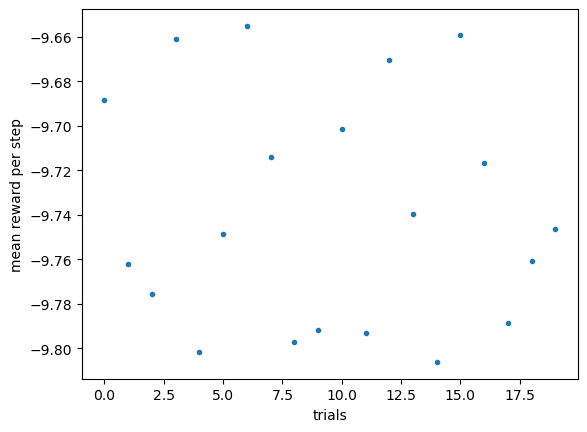

In [24]:
def rollout(actor_crit, env, N_rollout=10_000, sigma_u=1, deterministic=False, eval_mode=False, render=False, verbose=False): 
    #save the following (use .append)
    Start_state = [] #hold an array of (x_t)
    Actions = [] #hold an array of (u_t)
    Rewards = [] #hold an array of (r_{t+1})
    End_state = [] #hold an array of (x_{t+1})
    Terminal = [] #hold an array of (terminal_{t+1})
    #pi = lambda x: actor_crit.actor(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy()

    #if deterministic==False: pi = lambda x, sigma : actor_crit.actor(torch.tensor(x[None,:],dtype=torch.float32), sigma_u=sigma)[0].numpy()
    #else: pi = lambda x: actor_crit.deterministic_actor(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy()
    #pi = numpy_wrapper(actor_crit.actor)

    with torch.no_grad():
        obs, info = env.reset() 
        rewards_acc = 0
        for i in (range(N_rollout)): 
            #action = np.random.choice(env.action_space.n,p=pi(obs))
            #action = actor_crit.actor(state, sigma_u=sigma_u, deterministic=deterministic)

            #For now
            state = obs
            

            action = actor_crit.pi_p(state, sigma_u)
            
            if verbose: print(state, action)
            
            Start_state.append(obs) 
            Actions.append(action)

            obs_next, reward, terminated, truncated, info = env.step(action)
            lagrangian_reward = reward_custom(obs)
            rewards_acc += lagrangian_reward

            if render: env.render()
             
            Terminal.append(terminated)
            Rewards.append(lagrangian_reward) #Rewards.append(reward)
            End_state.append(obs_next) 

            if terminated or truncated: 
                obs, info = env.reset() 
            else:
                obs = obs_next
                
    #error checking:
    assert len(Start_state)==len(Actions)==len(Rewards)==len(End_state)==len(Terminal), f'error in lengths: {len(Start_state)}=={len(Actions)}=={len(Rewards)}=={len(End_state)}=={len(Terminal)}'
    if eval_mode==False: return np.array(Start_state), np.array(Actions), np.array(Rewards)/N_rollout, np.array(End_state), np.array(Terminal).astype(int)
    else: return rewards_acc/N_rollout

# env = gym.make('CartPole-v1')
actor_crit = ActorCritic()

Start_state, Actions, Rewards, End_state, Terminal = rollout(actor_crit,env,N_rollout=20, sigma_u=1, eval_mode=False, render=False)
print(f'Start_state={Start_state}')
print(f'Actions={Actions}')
print(f'Rewards={Rewards}')
print(f'End_state={End_state}')
print(f'Terminal={Terminal}')
plt.plot([rollout(actor_crit,env,N_rollout=20, sigma_u=1, eval_mode=True, render=True) for i in tqdm(range(20))],'.')
plt.xlabel("trials")
plt.ylabel("mean reward per step")

env.close()
plt.show()
#show(actor_crit,env)
#rollout(actor_crit,env,N_rollout=20, sigma_u=1, eval_mode=False, render=True)

In [23]:
def eval_actor(actor_crit, env):
    
    with torch.no_grad():
        rewards_acc = 0 
        obs, info = env.reset() 
        while True: 
            state = obs
            action = actor_crit.pi_d(state)
            obs, reward, terminated, truncated, info = env.step(action)
            rewards_acc += reward 
            if terminated or truncated: 
                return rewards_acc 

def show(actor_crit,env):
    #pi = lambda x: actor_crit.deterministic_actor(torch.tensor(x[None,:],dtype=torch.float32))[0].numpy()
    #pi = numpy_wrapper(actor_crit.deterministic_actor)
    with torch.no_grad():
        try:
            obs, info = env.reset() 
            env.render() 
            time.sleep(1) 
            while True: 
                state = obs
                action = actor_crit.pi_d(state)
                obs, reward, terminated, truncated, info = env.step(action) 
                # time.sleep(1/60) 
                env.render()
                if terminated or truncated: 
                    time.sleep(0.5) 
                    break  
        finally: #this will always run even when an error occurs
            env.close()
    
def softmax(h):
    hp = h-np.max(h)
    return np.exp(hp)/np.sum(np.exp(hp))